In [25]:
!pip install evaluate
!pip install seqeval

In [26]:
import pandas as pd
import re
from collections import Counter
import numpy as np
import matplotlib.pyplot as plt
import nltk
from nltk.util import ngrams
import math
nltk.download('punkt')
nltk.download('punkt_tab')
from nltk import FreqDist, ConditionalFreqDist
import torch
from sklearn.metrics import accuracy_score, precision_recall_fscore_support
from torch import nn
from tqdm.notebook import tqdm
from torch.utils.data import DataLoader, Dataset
from torch.optim import AdamW
from typing import List, Tuple
from transformers import MarianMTModel, MarianTokenizer, DistilBertTokenizerFast, TrainingArguments, Trainer
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM, AutoModelForTokenClassification, DataCollatorForTokenClassification
import torch
from tqdm import tqdm
import pandas as pd
import evaluate

## Load the dataset
splits = {'train': 'train.parquet', 'validation': 'validation.parquet'}
df_train = pd.read_parquet("hf://datasets/coastalcph/tydi_xor_rc/" + splits["train"])
df_val = pd.read_parquet("hf://datasets/coastalcph/tydi_xor_rc/" + splits["validation"])

# Only keep Arabic, Telugu and Korean examples
df_train = df_train[df_train['lang'].isin(['ar', 'te', 'ko'])]
df_val = df_val[df_val['lang'].isin(['ar', 'te', 'ko'])]


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


In [27]:
[(row['context'][row['answer_start']:row['answer_start']+len(row['answer'])], row['answer']) for _, row in df_train.iterrows()]

[('France', 'France'),
 ('Wilhelm Röntgen', 'Wilhelm Röntgen'),
 ('2004', '2004'),
 ('British Broadcasting Corporation (BBC)',
  'British Broadcasting Corporation (BBC)'),
 ('Jerusalem', 'Jerusalem'),
 ('Andromeda', 'Andromeda'),
 ('Smith–Putnam wind turbine', 'Smith–Putnam wind turbine'),
 ('Louis, Dauphin', 'Louis, Dauphin'),
 ('CBS', 'CBS'),
 ('Chandragupta Maurya', 'Chandragupta Maurya'),
 ('appointed "Reichsführer-SS" by Hitler',
  'appointed "Reichsführer-SS" by Hitler'),
 ('Silicon', 'Silicon'),
 ('1945', '1945'),
 ('Subway', 'Subway'),
 ('22 November 2005', '22 November 2005'),
 ('London', 'London'),
 ('USSR', 'USSR'),
 ('', 'no'),
 ('one-quarter', 'one-quarter'),
 ('Vertigo', 'Vertigo'),
 ('7th place', '7th place'),
 ('Charles Darwin', 'Charles Darwin'),
 ('Islamic State', 'Islamic State'),
 ('Revelation', 'Revelation'),
 ('UuU', 'UuU'),
 ('Sydney', 'Sydney'),
 ('"MUD1"', '"MUD1"'),
 ('2,932, excluding military personnel serving in the archipelago and their dependents. A 2012 

In [28]:
modelName = "distilbert-base-multilingual-cased"


tokenizer = AutoTokenizer.from_pretrained(modelName)


In [29]:
def create_bio_tags_and_indices(context, answer_start, answer, tokenizer):
    """
    Creates BIO tags and indices for a given context and answer.
    """

    encoded = tokenizer(
        context,
        return_offsets_mapping = True,
        add_special_tokens = False
    )

    tokens = tokenizer.convert_ids_to_tokens(encoded["input_ids"])
    offsets = encoded["offset_mapping"]

    # Initialize all tags as O
    tags = ["O"] * len(tokens)

    # Assign BIO tags
    if not pd.isna(answer_start) and not pd.isna(answer):
        answer_end = answer_start + len(answer) # If answer exists
        inside_answer  = False
        for i, (start, end) in enumerate(offsets):

            if end <= answer_start or start >= answer_end: # If current token is outside of answer span, ignore
                continue
            if not inside_answer: # If we have not found any answer yet, first one is B-ANS
                tags[i] = "B-ANS"
                inside_answer = True
            else:
                tags[i] = "I-ANS" # Remaining part of answer is I-ANS
    else:
        inside_answer = False

    # Return structured token data
    token_data = [
        {"word": tok, "start": s, "end": e, "tag": tag}
        for tok, (s, e), tag in zip(tokens, offsets, tags)
    ]

    return token_data

In [30]:

# Mapping from BIO to 012 and reverse
tag2id = {"O": 0, "B-ANS": 1, "I-ANS": 2}
id2tag = {v: k for k, v in tag2id.items()}

def encode_example(example, tokenizer, tag2id=tag2id, max_length=512):
    encoding = tokenizer(example["question"], example["context"],
                         truncation="only_second", max_length=max_length,
                         padding ="max_length",
                         return_offsets_mapping=True)
    word_ids = encoding.word_ids()
    labels = []
    for idx, word_id in enumerate(word_ids):
        if word_id is None:
            labels.append(-100)
        else:
            start, end = example["answer_start"], example["answer_start"] + len(example["answer"])
            token_start, token_end = encoding["offset_mapping"][idx]
            if token_end <= start or token_start >= end:
                labels.append(tag2id["O"])
            else:
                labels.append(tag2id["B-ANS"] if idx == 0 or labels[-1] in [tag2id["O"], -100] else tag2id["I-ANS"])
    encoding["labels"] = labels

    encoding.pop("offset_mapping")


    return encoding



In [31]:
index = 10

example_row = {
    "question": df_train.iloc[index]['question'],
    "context": df_train.iloc[index]['context'],
    "answer_start": df_train.iloc[index]['answer_start'],
    "answer": df_train.iloc[index]['answer']
}

encoded_example = encode_example(example_row, tokenizer)

tokens = tokenizer.convert_ids_to_tokens(encoded_example["input_ids"])
labels = encoded_example["labels"]

# Print tokens og deres label (brug id2tag)
for tok, lab in zip(tokens, labels):
    label_str = id2tag[lab] if lab != -100 else "PAD/IGN"
    print(f"{tok:15} -> {label_str}")

[CLS]           -> PAD/IGN
히               -> O
##틀             -> O
##러             -> O
##와             -> O
힘               -> O
##러             -> O
##는             -> O
무               -> O
##슨             -> O
관               -> O
##계             -> O
##였             -> O
##는             -> O
##가             -> O
?               -> O
[SEP]           -> PAD/IGN
As              -> O
a               -> O
member          -> O
of              -> O
a               -> O
reserve         -> O
battalion       -> O
during          -> O
World           -> O
War             -> O
I               -> O
,               -> O
Himmler         -> O
did             -> O
not             -> O
see             -> O
active          -> O
service         -> O
.               -> O
He              -> O
studied         -> O
ag              -> O
##rono          -> O
##my            -> O
in              -> O
university      -> O
,               -> O
and             -> O
joined          -> O
the             -> O
N

In [32]:
# Process the specific row from the DataFrame
context = df_train.iloc[index]['context']
answer_start = df_train.iloc[index]['answer_start']
answer = df_train.iloc[index]['answer']

# Get the tagged tokens
tagged_tokens = create_bio_tags_and_indices(context, answer_start, answer, tokenizer)

# Print the output in the user's desired format
for token in tagged_tokens:
    print(f"{token['word']:15} -> {token['tag']:>2} -> ({token['start']},{token['end']})")

As              ->  O -> (0,2)
a               ->  O -> (3,4)
member          ->  O -> (5,11)
of              ->  O -> (12,14)
a               ->  O -> (15,16)
reserve         ->  O -> (17,24)
battalion       ->  O -> (25,34)
during          ->  O -> (35,41)
World           ->  O -> (42,47)
War             ->  O -> (48,51)
I               ->  O -> (52,53)
,               ->  O -> (53,54)
Himmler         ->  O -> (55,62)
did             ->  O -> (63,66)
not             ->  O -> (67,70)
see             ->  O -> (71,74)
active          ->  O -> (75,81)
service         ->  O -> (82,89)
.               ->  O -> (89,90)
He              ->  O -> (91,93)
studied         ->  O -> (94,101)
ag              ->  O -> (102,104)
##rono          ->  O -> (104,108)
##my            ->  O -> (108,110)
in              ->  O -> (111,113)
university      ->  O -> (114,124)
,               ->  O -> (124,125)
and             ->  O -> (126,129)
joined          ->  O -> (130,136)
the             ->  O -> (137,1

In [33]:
def tokenize_dataset(df, tokenizer):
    encoded_list = []
    for _, row in tqdm(df.iterrows(), total=len(df)):
        example = {
            "question": row["question"],
            "context": row["context"],
            "answer_start": row["answer_start"],
            "answer": row["answer"]
        }
        encoded = encode_example(example, tokenizer)
        encoded_list.append(encoded)
    return encoded_list


In [34]:
device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")
print("Using device:", device)

model = AutoModelForTokenClassification.from_pretrained(
    modelName,
    num_labels= 3,
    id2label={0: "O", 1: "B-ANS", 2: "I-ANS"},
    label2id={"O": 0, "B-ANS": 1, "I-ANS": 2}
)

model.to(device)

training_args = TrainingArguments(
    output_dir=".bioqa-model1",
    eval_strategy = "epoch",
    learning_rate = 2e-5,
    per_device_train_batch_size = 32,
    num_train_epochs = 5,
    weight_decay = 0.01,
    save_total_limit = 2,
    logging_dir="./logs",
    logging_steps = 50,
    report_to = "none"
)

Some weights of DistilBertForTokenClassification were not initialized from the model checkpoint at distilbert-base-multilingual-cased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Using device: cuda


In [35]:
data_collator = DataCollatorForTokenClassification(tokenizer)

seqeval_metric = evaluate.load("seqeval")

def compute_qa_metrics(p):
    """
    Beregner token-level metrics, span-level metrics og EM/F1 for BIO question answering.

    Args:
        p: Tuple (predictions, labels) fra modellen
        id2tag: Dict, mapping fra id til tag (B/I/O)

    Returns:
        dict med alle relevante metrics
    """
    predictions, labels = p
    predictions = predictions.argmax(-1)

    # Konverter til tag-strings, ignorer labels med -100
    true_predictions = [
        [id2tag[pred] for pred, lab in zip(prediction, label) if lab != -100]
        for prediction, label in zip(predictions, labels)
    ]
    true_labels = [
        [id2tag[lab] for pred, lab in zip(prediction, label) if lab != -100]
        for prediction, label in zip(predictions, labels)
    ]

    # Token-level metrics via seqeval
    seqeval_results = seqeval_metric.compute(predictions=true_predictions, references=true_labels)

    # Span-level metrics: Exact Match og F1 (overlap)
    def bio_to_spans(tags):
        """Konverter BIO-tags til spans som (start_idx, end_idx)."""
        spans = []
        start = None
        for i, tag in enumerate(tags):
            if tag.startswith("B"):
                if start is not None:
                    spans.append((start, i-1))
                start = i
            elif tag == "O":
                if start is not None:
                    spans.append((start, i-1))
                    start = None
        if start is not None:
            spans.append((start, len(tags)-1))
        return spans

    exact_matches = []
    f1_scores = []

    for pred_tags, true_tags in zip(true_predictions, true_labels):
        pred_spans = bio_to_spans(pred_tags)
        true_spans = bio_to_spans(true_tags)

        # Exact Match
        exact_matches.append(int(pred_spans == true_spans))

        # Token-level overlap F1
        pred_tokens = set()
        for start, end in pred_spans:
            pred_tokens.update(range(start, end+1))
        true_tokens = set()
        for start, end in true_spans:
            true_tokens.update(range(start, end+1))

        tp = len(pred_tokens & true_tokens)
        fp = len(pred_tokens - true_tokens)
        fn = len(true_tokens - pred_tokens)
        precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
        recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
        f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0.0
        f1_scores.append(f1)

    # Start/End token accuracy
    start_correct = 0
    end_correct = 0
    total = len(true_predictions)
    for pred_tags, true_tags in zip(true_predictions, true_labels):
        pred_spans = bio_to_spans(pred_tags)
        true_spans = bio_to_spans(true_tags)
        if pred_spans and true_spans:
            start_correct += int(pred_spans[0][0] == true_spans[0][0])
            end_correct += int(pred_spans[-1][1] == true_spans[-1][1])
        else:
            # Hvis ingen span, tælles som korrekt kun hvis begge ingen
            start_correct += int(pred_spans == true_spans)
            end_correct += int(pred_spans == true_spans)

    metrics = {
        "token_precision": seqeval_results["overall_precision"],
        "token_recall": seqeval_results["overall_recall"],
        "token_f1": seqeval_results["overall_f1"],
        "token_accuracy": seqeval_results["overall_accuracy"],
        "span_exact_match": np.mean(exact_matches),
        "span_f1": np.mean(f1_scores),
        "start_accuracy": start_correct / total,
        "end_accuracy": end_correct / total
    }

    return metrics


In [36]:
class_weights = torch.tensor([1.0, 5.0, 2.5]).to(device)


class WeightedTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.get("labels")
        outputs = model(**inputs)
        logits = outputs.logits
        loss_fn = torch.nn.CrossEntropyLoss(weight=class_weights, ignore_index=-100)
        loss = loss_fn(logits.view(-1, logits.size(-1)), labels.view(-1))
        return (loss, outputs) if return_outputs else loss



class WeightedTokenClassificationModel(nn.Module):
    def __init__(self, model, class_weights):
        super().__init__()
        self.model = model
        self.class_weights = class_weights
        self.loss_fn = nn.CrossEntropyLoss(weight=class_weights, ignore_index=-100)

    def forward(self, input_ids=None, attention_mask=None, labels=None):
        outputs = self.model(input_ids=input_ids, attention_mask=attention_mask)
        logits = outputs.logits  # (batch, seq_len, num_labels)
        loss = None
        if labels is not None:
            loss = self.loss_fn(logits.view(-1, logits.size(-1)), labels.view(-1))
        return {'loss': loss, 'logits': logits}

weighted_model = WeightedTokenClassificationModel(model, class_weights)


In [37]:
train_n = 1000
val_m = 500

train_subset = df_train.sample(n=train_n, random_state=42)
val_subset   = df_val.sample(n=val_m, random_state=42)


encoded_train = tokenize_dataset(df_train, tokenizer)
encoded_val = tokenize_dataset(df_val, tokenizer)

trainer = WeightedTrainer(
    model=model,                   # din AutoModelForTokenClassification
    args=training_args,
    train_dataset=encoded_train,
    eval_dataset=encoded_val,
    tokenizer=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_qa_metrics
)

100%|██████████| 1155/1155 [00:01<00:00, 740.04it/s]
/tmp/ipython-input-3592783438.py:11: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `WeightedTrainer.__init__`. Use `processing_class` instead.
  trainer = WeightedTrainer(


In [38]:
trainer.train()

results = trainer.evaluate()
print(results)

Epoch,Training Loss,Validation Loss,Token Precision,Token Recall,Token F1,Token Accuracy,Span Exact Match,Span F1,Start Accuracy,End Accuracy
1,0.296900,0.273148,0.155386,0.205549,0.176982,0.956765,0.051948,0.234462,0.245887,0.141126
2,0.260400,0.255072,0.155744,0.266709,0.196653,0.953316,0.055411,0.296787,0.285714,0.183550
3,0.234800,0.259663,0.155826,0.282472,0.200852,0.952122,0.066667,0.323067,0.289177,0.201732
4,0.199100,0.263663,0.159884,0.277427,0.202858,0.952117,0.066667,0.323111,0.298701,0.219913
5,0.184000,0.271979,0.157676,0.287516,0.203662,0.950790,0.069264,0.332776,0.312554,0.221645


{'eval_loss': 0.27197936177253723, 'eval_token_precision': 0.15767634854771784, 'eval_token_recall': 0.287515762925599, 'eval_token_f1': 0.20366234926306387, 'eval_token_accuracy': 0.9507896315052975, 'eval_span_exact_match': 0.06926406926406926, 'eval_span_f1': 0.3327756945225919, 'eval_start_accuracy': 0.31255411255411253, 'eval_end_accuracy': 0.22164502164502164, 'eval_runtime': 18.5204, 'eval_samples_per_second': 62.364, 'eval_steps_per_second': 7.829, 'epoch': 5.0}


In [39]:
def debug_tokenization(context, answer_start, answer, tokenizer, label2id):
    # 1. Lav dine BIO-tags på ordniveau
    tokens = context.split()
    tags = ["O"] * len(tokens)

    # Find hvor svaret begynder
    answer_tokens = answer.split()
    for i, token in enumerate(tokens):
        if " ".join(tokens[i:i+len(answer_tokens)]) == answer:
            tags[i] = "B-ANS"
            for j in range(1, len(answer_tokens)):
                tags[i+j] = "I-ANS"
            break

    # 2. Tokenizér med is_split_into_words=True (så vi kan holde styr på hvilke ord der bliver splittet)
    encoding = tokenizer(tokens, is_split_into_words=True, return_offsets_mapping=True, truncation=True, padding="longest")

    # 3. Map BIO-tags fra ordniveau til token-niveau
    word_ids = encoding.word_ids()
    labels = []
    for word_idx in word_ids:
        if word_idx is None:
            labels.append(-100)
        else:
            labels.append(label2id[tags[word_idx]])

    # 4. Print sammenligning
    print(f"{'Token':20} {'WordID':6} {'LabelID':7} Label")
    print("-" * 50)
    for token, w_id, l_id in zip(tokenizer.convert_ids_to_tokens(encoding['input_ids']), word_ids, labels):
        label = [k for k,v in label2id.items() if v == l_id][0] if l_id != -100 else "IGN"
        print(f"{token:20} {str(w_id):6} {str(l_id):7} {label}")


In [40]:
all_labels = []
for ex in encoded_train:
    all_labels.extend([l for l in ex["labels"] if l != -100])

Counter(all_labels)

Counter({0: 907714, 1: 8296, 2: 31470})

In [41]:
index = 10
example_row = {
    "question": df_train.iloc[index]["question"],
    "context": df_train.iloc[index]["context"],
    "answer_start": df_train.iloc[index]["answer_start"],
    "answer": df_train.iloc[index]["answer"]
}

encoded_ex = encode_example(example_row, tokenizer)
tokens = tokenizer.convert_ids_to_tokens(encoded_ex["input_ids"])

for t, sid, l in zip(tokens, encoded_ex.sequence_ids(), encoded_ex["labels"]):
    print(f"{t:<15}  seq={sid}  {id2tag.get(l, 'IGN')}")


[CLS]            seq=None  IGN
히                seq=0  O
##틀              seq=0  O
##러              seq=0  O
##와              seq=0  O
힘                seq=0  O
##러              seq=0  O
##는              seq=0  O
무                seq=0  O
##슨              seq=0  O
관                seq=0  O
##계              seq=0  O
##였              seq=0  O
##는              seq=0  O
##가              seq=0  O
?                seq=0  O
[SEP]            seq=None  IGN
As               seq=1  O
a                seq=1  O
member           seq=1  O
of               seq=1  O
a                seq=1  O
reserve          seq=1  O
battalion        seq=1  O
during           seq=1  O
World            seq=1  O
War              seq=1  O
I                seq=1  O
,                seq=1  O
Himmler          seq=1  O
did              seq=1  O
not              seq=1  O
see              seq=1  O
active           seq=1  O
service          seq=1  O
.                seq=1  O
He               seq=1  O
studied          seq=1  O
ag

Token indices sequence length is longer than the specified maximum sequence length for this model (587 > 512). Running this sequence through the model will result in indexing errors


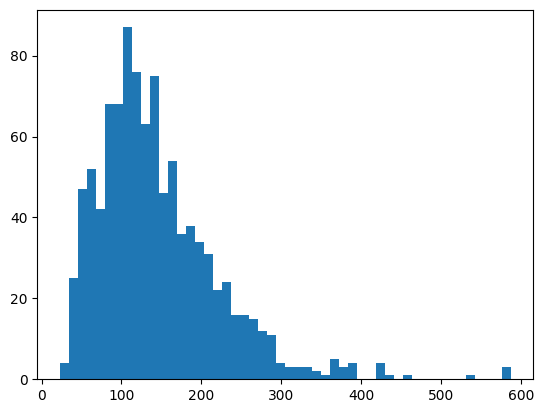

In [42]:
lengths = [len(tokenizer(q, c)["input_ids"]) for q, c in zip(train_subset["question"], train_subset["context"])]
import matplotlib.pyplot as plt
plt.hist(lengths, bins=50)
plt.show()

In [43]:
# 1️⃣ Sample a few examples from validation set
sample_val = df_val.sample(5, random_state=42)
encoded_sample = [encode_example(row, tokenizer) for _, row in sample_val.iterrows()]

# 2️⃣ Make predictions with the model
model.eval()
predictions = []

for enc in encoded_sample:
    input_ids = torch.tensor([enc["input_ids"]]).to(device)
    attention_mask = torch.tensor([enc["attention_mask"]]).to(device)

    with torch.no_grad():
        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        logits = outputs.logits
        pred_ids = torch.argmax(logits, dim=-1).squeeze().cpu().numpy()
        predictions.append(pred_ids)

# 3️⃣ Convert predicted IDs to BIO tags
pred_tags = []
for pred, enc in zip(predictions, encoded_sample):
    tags = []
    for id, label in zip(pred, enc["labels"]):
        if label == -100:
            tags.append("IGN")  # ignore tokens
        else:
            tags.append(id2tag[id])
    pred_tags.append(tags)

# 4️⃣ Print token-level comparison
for i, enc in enumerate(encoded_sample):
    tokens = tokenizer.convert_ids_to_tokens(enc["input_ids"])
    print(f"\nExample {i+1}: {sample_val.iloc[i]['question']}")
    for t, pred_tag, true_id in zip(tokens, pred_tags[i], enc["labels"]):
        true_tag = id2tag.get(true_id, "IGN") if true_id != -100 else "IGN"
        print(f"{t:15} Pred: {pred_tag:5} True: {true_tag}")

# 5️⃣ Function to reconstruct predicted answers as text
def tokens_to_text(tokens, tags):
    answer = ""
    inside = False
    for tok, tag in zip(tokens, tags):
        if tag == "B-ANS":
            if inside:
                answer += " "
            answer += tok.replace("##", "")
            inside = True
        elif tag == "I-ANS" and inside:
            answer += tok.replace("##", "")
        else:
            inside = False
    return answer

# 6️⃣ Show predicted vs ground truth answers
for i, enc in enumerate(encoded_sample):
    tokens = tokenizer.convert_ids_to_tokens(enc["input_ids"])
    pred_answer = tokens_to_text(tokens, pred_tags[i])
    true_answer = sample_val.iloc[i]["answer"]
    question = sample_val.iloc[i]["question"]
    print(f"\nQuestion: {question}")
    print(f"Predicted answer: {pred_answer}")
    print(f"Ground truth:    {true_answer}")


for enc in encoded_sample:
    print(enc["labels"])


Example 1: ما معنى كلمة الهاجاناه بالعبرية؟
[CLS]           Pred: IGN   True: IGN
ما              Pred: O     True: O
مع              Pred: O     True: O
##نى            Pred: O     True: O
كلمة            Pred: O     True: O
ال              Pred: O     True: O
##ها            Pred: O     True: O
##جان           Pred: O     True: B-ANS
##اه            Pred: O     True: I-ANS
با              Pred: O     True: I-ANS
##ل             Pred: O     True: I-ANS
##عب            Pred: O     True: I-ANS
##رية           Pred: O     True: O
؟               Pred: O     True: O
[SEP]           Pred: IGN   True: IGN
Ha              Pred: B-ANS True: O
##gana          Pred: O     True: O
##h             Pred: O     True: O
(               Pred: O     True: O
,               Pred: O     True: O
lit             Pred: O     True: O
.               Pred: O     True: O
"               Pred: O     True: O
The             Pred: O     True: B-ANS
Defence         Pred: O     True: I-ANS
"               Pred: O

In [44]:
import numpy as np
all_labels = np.concatenate([enc["labels"] for enc in encoded_sample])
unique, counts = np.unique(all_labels, return_counts=True)
print(dict(zip(unique, counts)))


{np.int64(-100): np.int64(1775), np.int64(0): np.int64(764), np.int64(1): np.int64(8), np.int64(2): np.int64(13)}
